# LO benchmark results (v5)

Load multi-model results for the linear-optimization (LO / LP) benchmark into one dataframe, then show a **score table**: rows = vignette × version, columns = LLMs.

Task: `lo_normative_accuracy_5` / Kaggle slug `lo-normative-accuracy-5` (**9 vignettes × 4 prompt variants = 36 prompts**).

Each cell is `1` if the model was keyed-correct (JSON `cost` within 1% of the keyed objective, or correct A/B for audits), else `0`.

**Download in this notebook:** the load cell sets `DOWNLOAD_KAGGLE_RUNS = True` and pulls runs via the Kaggle CLI into `data/kaggle_runs/lo-normative-accuracy-5`. Set `FORCE_DOWNLOAD_KAGGLE_RUNS = True` to pass `-f` and replace existing run folders (without it, Kaggle skips re-download). Requires `kaggle auth login` once.

If download is off and files are missing, the cell will still try to download automatically.

**Opus dry-run overlay:** if `data/lp/lp_merged_results_opus.csv` exists, the load cell replaces that model's rows from the Kaggle run download with the CSV (so incomplete published Opus runs don't leave NaNs).

**Kaggle dashboard:** dry-run/CSV overlay does not update the Task leaderboard. To fix the dashboard, publish a completed Opus run (`CANDIDATE_LLMS` Opus → dry-run optional → `lo_normative_accuracy_5.run(opus)` → `%choose` / Build), then force-download for a permanent run-tree update.


In [1]:
# ! \src\projects\sceptical_llms\.venv\Scripts\python.exe -m kaggle auth logina/

In [2]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "data" / "lp").is_dir():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import benchmarks.kaggle_runs as kaggle_runs
import benchmarks.lp_rate as lp_rate

importlib.reload(lp_rate)
importlib.reload(kaggle_runs)

from benchmarks.kaggle_runs import (
    DEFAULT_LO_TASK_SLUG,
    download_task_runs,
    load_base_rate_run_rows_from_tree,
    merged_lo_results_from_kaggle_runs,
)
from benchmarks.lp_rate import write_merged_results_csv

# --- knobs ---
LOAD_FROM_KAGGLE = True
DOWNLOAD_KAGGLE_RUNS = True  # download via Kaggle CLI into data/kaggle_runs/...
FORCE_DOWNLOAD_KAGGLE_RUNS = True  # pass -f so existing run folders are replaced
# Task published by %choose lo_normative_accuracy_5
KAGGLE_TASK_SLUG = DEFAULT_LO_TASK_SLUG  # "lo-normative-accuracy-5"
assert KAGGLE_TASK_SLUG == "lo-normative-accuracy-5", KAGGLE_TASK_SLUG

# Sandbox / alternate run folders (first existing wins when LOAD_FROM_KAGGLE).
SANDBOX_CANDIDATES = [
    ROOT / "data" / "kaggle_runs" / "lo-normative-accuracy-5",
    Path("/kaggle/working") / "lp_benchmark",
    Path("/kaggle/working"),
]

BENCHMARK_CSV = ROOT / "data" / "lp" / "benchmark.csv"
MERGED_DIR = ROOT / "data" / "lp"
# Dry-run Opus CSV downloaded from Kaggle /kaggle/working/lp_merged_results.csv
OPUS_OVERRIDE_CSV = MERGED_DIR / "lp_merged_results_opus.csv"


def _first_existing(paths: list[Path]) -> Path | None:
    for path in paths:
        if path.is_dir() and (
            any(path.rglob("*.run.json")) or any(path.glob("*merged*.csv"))
        ):
            return path
    return None


def _load_merged_from_run_tree(runs_dir: Path) -> tuple[pd.DataFrame, str]:
    try:
        merged_rows = merged_lo_results_from_kaggle_runs(
            runs_dir,
            benchmark_path=BENCHMARK_CSV,
            fill_missing=False,
        )
    except ValueError:
        # Fallback for sandbox trees that do not match the task-slug filter path.
        run_rows = load_base_rate_run_rows_from_tree(runs_dir)
        if not run_rows:
            raise
        out_csv = MERGED_DIR / "lo_merged_results.csv"
        write_merged_results_csv(
            run_rows,
            out_csv,
            benchmark_path=BENCHMARK_CSV,
        )
        merged_rows = pd.read_csv(out_csv).to_dict(orient="records")
    return pd.DataFrame(merged_rows), f"run tree ({runs_dir})"


if LOAD_FROM_KAGGLE:
    default_runs = ROOT / "data" / "kaggle_runs" / KAGGLE_TASK_SLUG
    if DOWNLOAD_KAGGLE_RUNS:
        print(
            f"Downloading {KAGGLE_TASK_SLUG} -> {default_runs}"
            + (" (force)" if FORCE_DOWNLOAD_KAGGLE_RUNS else "")
        )
        default_runs.mkdir(parents=True, exist_ok=True)
        download_task_runs(
            KAGGLE_TASK_SLUG,
            default_runs,
            force=FORCE_DOWNLOAD_KAGGLE_RUNS,
        )

    # Prefer the current task download dir (lo-normative-accuracy-5).
    runs_dir = _first_existing([default_runs, *SANDBOX_CANDIDATES])
    if runs_dir is None and not DOWNLOAD_KAGGLE_RUNS:
        print(f"No local runs found; downloading {KAGGLE_TASK_SLUG} -> {default_runs}")
        default_runs.mkdir(parents=True, exist_ok=True)
        download_task_runs(KAGGLE_TASK_SLUG, default_runs)
        runs_dir = _first_existing([default_runs, *SANDBOX_CANDIDATES])

    if runs_dir is None:
        raise FileNotFoundError(
            "No LO run results found after download attempt. Looked under:\n  - "
            + "\n  - ".join(str(p) for p in [default_runs, *SANDBOX_CANDIDATES])
            + f"\nManual download:\n  python -m kaggle benchmarks tasks download "
            f"{KAGGLE_TASK_SLUG} -o {default_runs}"
        )

    if any(runs_dir.rglob("*.run.json")):
        df, data_source = _load_merged_from_run_tree(runs_dir)
    else:
        merged_csv = sorted(
            runs_dir.glob("*merged*.csv"),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )[0]
        df = pd.read_csv(merged_csv)
        data_source = str(merged_csv)
else:
    merged_candidates = sorted(
        list(MERGED_DIR.glob("*merged*.csv"))
        + list(MERGED_DIR.glob("lo_merged_results*.csv")),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    # De-dupe while preserving mtime order.
    seen: set[Path] = set()
    unique: list[Path] = []
    for path in merged_candidates:
        if path not in seen:
            seen.add(path)
            unique.append(path)
    if not unique:
        raise FileNotFoundError(
            f"Missing merged results under {MERGED_DIR}. "
            "Set LOAD_FROM_KAGGLE=True or run benchmark/lo-benchmark.ipynb."
        )
    merged_csv = unique[0]
    df = pd.read_csv(merged_csv)
    data_source = str(merged_csv)

# Replace incomplete published Opus rows with a local dry-run CSV, if present.
if OPUS_OVERRIDE_CSV.is_file():
    opus_df = pd.read_csv(OPUS_OVERRIDE_CSV)
    if "model" not in opus_df.columns:
        raise KeyError(f"{OPUS_OVERRIDE_CSV} missing 'model' column")
    overlay_models = sorted(opus_df["model"].dropna().astype(str).unique())
    before = len(df)
    if "model" in df.columns and len(overlay_models):
        df = df[~df["model"].astype(str).isin(overlay_models)].copy()
    df = pd.concat([df, opus_df], ignore_index=True)
    data_source = f"{data_source} + overlay {OPUS_OVERRIDE_CSV.name}"
    print(
        f"Overlaid {OPUS_OVERRIDE_CSV.name}: models={overlay_models}; "
        f"rows {before} -> {len(df)} (+{len(opus_df)} opus rows)"
    )

if "score" not in df.columns:
    raise KeyError("Merged data must include 'score'.")

df["score_value"] = df["score"].astype(str).str.lower().eq("true").astype(int)
if "naive_lp_confusion" in df.columns:
    df["naive_value"] = (
        df["naive_lp_confusion"].astype(str).str.lower().eq("true").astype(int)
    )

print("Source:", data_source)
print("Task slug:", KAGGLE_TASK_SLUG)
print("Rows:", len(df))
print("Models:", sorted(df["model"].dropna().unique()))
print("Questions:", sorted(df["example_id"].unique()) if "example_id" in df else "?")

# Count missing model×prompt cells (these become NaNs in the score pivots).
if {"model", "example_id"}.issubset(df.columns) and BENCHMARK_CSV.is_file():
    expected_ids = set(pd.read_csv(BENCHMARK_CSV)["example_id"].astype(str))
    models = [m for m in sorted(df["model"].dropna().unique().tolist())]
    have = {
        (str(m), str(e))
        for m, e in zip(df["model"], df["example_id"], strict=False)
        if pd.notna(m) and pd.notna(e)
    }
    missing_pairs = [
        (m, e) for m in models for e in sorted(expected_ids) if (m, e) not in have
    ]
    print(
        f"Missing scores (model×prompt): {len(missing_pairs)} "
        f"/ {len(models) * len(expected_ids)} expected"
    )
    if missing_pairs:
        by_model = (
            pd.Series([m for m, _ in missing_pairs], dtype=str)
            .value_counts()
            .sort_index()
        )
        print("Missing by model:")
        for model_name, n_missing in by_model.items():
            print(f"  {model_name}: {n_missing}")

df.head()


Source: run tree (c:\src2\sceptical-llms\data\kaggle_runs\lo-normative-accuracy-5)
Task slug: lo-normative-accuracy-5
Rows: 373
Models: ['anthropic/claude-haiku-4-5@20251001', 'anthropic/claude-opus-4-8@default', 'anthropic/claude-opus-5@default', 'anthropic/claude-sonnet-4-6@default', 'google/gemini-2.5-flash', 'google/gemini-3-flash-preview', 'google/gemini-3.5-flash', 'google/gemini-3.5-flash-lite', 'google/gemini-3.6-flash', 'openai/gpt-5.6-sol', 'openai/gpt-5.6-terra']
Questions: ['carpenter_furniture__integrality__detects_tacit_violation', 'carpenter_furniture__integrality__explicit__json', 'carpenter_furniture__integrality__json', 'carpenter_furniture__integrality__needs_tacit_constraint', 'charter_buses__integrality__detects_tacit_violation', 'charter_buses__integrality__explicit__json', 'charter_buses__integrality__json', 'charter_buses__integrality__needs_tacit_constraint', 'coffee_roaster__fractional_ok__detects_tacit_violation', 'coffee_roaster__fractional_ok__explicit__jso

,example_id,vignette_name,failure_mode,condition,problem_type,intersection_size,response_type,has_statistics,variant,prompt,...,parsed_confidence,comment_line,scoring_type,parseable,score,naive_lp_confusion,parsed_objective,parsed_solution,score_value,naive_value
0,carpenter_furniture__integrality__detects_taci...,carpenter furniture,integrality,implicit,detects_tacit_violation,,detects_tacit_violation,true,detects_tacit_violation,"You are an operations auditor, checking a prop...",...,,,mc_numeric,true,true,false,,,1,0
1,carpenter_furniture__integrality__detects_taci...,carpenter furniture,integrality,implicit,detects_tacit_violation,,detects_tacit_violation,true,detects_tacit_violation,"You are an operations auditor, checking a prop...",...,,,mc_numeric,true,true,false,,,1,0
2,carpenter_furniture__integrality__detects_taci...,carpenter furniture,integrality,implicit,detects_tacit_violation,,detects_tacit_violation,true,detects_tacit_violation,"You are an operations auditor, checking a prop...",...,,,mc_numeric,true,true,false,,,1,0
3,carpenter_furniture__integrality__detects_taci...,carpenter furniture,integrality,implicit,detects_tacit_violation,,detects_tacit_violation,true,detects_tacit_violation,"You are an operations auditor, checking a prop...",...,,,mc_numeric,true,true,false,,,1,0
4,carpenter_furniture__integrality__detects_taci...,carpenter furniture,integrality,implicit,detects_tacit_violation,,detects_tacit_violation,true,detects_tacit_violation,"You are an operations auditor, checking a prop...",...,,,mc_numeric,true,true,false,,,1,0


## Leaderboard-style score table

Average keyed score by **prompt version** × **model** (same grain as a typical leaderboard panel). Cell = mean of 0/1 keyed scores across vignettes. Below: the same table transposed (models as rows).


In [3]:
# Prompt "version": JSON implicit/explicit, or audit variant name.
leaderboard_df = df.copy()
if "variant" in leaderboard_df.columns:
    leaderboard_df["version"] = leaderboard_df.apply(
        lambda r: (
            str(r.get("condition") or "")
            if str(r.get("variant") or "") == "json"
            else str(r.get("variant") or "")
        ),
        axis=1,
    )
elif "condition" in leaderboard_df.columns:
    leaderboard_df["version"] = leaderboard_df["condition"].astype(str)
else:
    raise KeyError("Need variant/condition to build leaderboard versions")

version_order = [
    "implicit",
    "explicit",
    "needs_tacit_constraint",
    "detects_tacit_violation",
    "control",
]

leaderboard_by_version = (
    leaderboard_df.pivot_table(
        index="version",
        columns="model",
        values="score_value",
        aggfunc="mean",
    )
    .reindex([v for v in version_order if v in leaderboard_df["version"].unique()])
    .sort_index(axis=1)
)
leaderboard_by_version["mean"] = leaderboard_by_version.mean(axis=1)
_col_means = leaderboard_by_version.drop(columns=["mean"]).mean(axis=0)
_mean_row = _col_means.copy()
_mean_row["mean"] = float(_col_means.mean())
leaderboard_by_version.loc["mean"] = _mean_row.to_numpy()

print("Rows = version, columns = model")
display(leaderboard_by_version.round(3))

leaderboard_by_model = (
    leaderboard_df.pivot_table(
        index="model",
        columns="version",
        values="score_value",
        aggfunc="mean",
    )
    .reindex(
        columns=[c for c in version_order if c in leaderboard_df["version"].unique()]
    )
    .sort_index(axis=0)
)
leaderboard_by_model["mean"] = leaderboard_by_model.mean(axis=1)
_col_means_m = leaderboard_by_model.drop(columns=["mean"]).mean(axis=0)
_mean_row_m = _col_means_m.copy()
_mean_row_m["mean"] = float(_col_means_m.mean())
leaderboard_by_model.loc["mean"] = _mean_row_m.to_numpy()

print("Rows = model, columns = version")
display(leaderboard_by_model.round(3))


Rows = version, columns = model


model,anthropic/claude-haiku-4-5@20251001,anthropic/claude-opus-4-8@default,anthropic/claude-opus-5@default,anthropic/claude-sonnet-4-6@default,google/gemini-2.5-flash,google/gemini-3-flash-preview,google/gemini-3.5-flash,google/gemini-3.5-flash-lite,google/gemini-3.6-flash,openai/gpt-5.6-sol,openai/gpt-5.6-terra,mean
version,,,,,,,,,,,,
implicit,0.222,0.444,0.833,0.556,0.111,0.444,0.556,0.111,0.444,0.500,0.111,0.394
explicit,0.222,0.556,0.667,0.778,0.111,0.556,0.556,0.111,0.444,0.333,0.222,0.414
needs_tacit_constraint,0.889,1.000,1.000,0.889,0.889,1.000,0.889,1.000,0.889,1.000,1.000,0.949
detects_tacit_violation,1.000,0.778,0.833,0.889,1.000,1.000,1.000,0.778,0.889,1.000,0.889,0.914
mean,0.583,0.694,0.833,0.778,0.528,0.750,0.750,0.500,0.667,0.708,0.556,0.668


Rows = model, columns = version


version,implicit,explicit,needs_tacit_constraint,detects_tacit_violation,mean
model,,,,,
anthropic/claude-haiku-4-5@20251001,0.222,0.222,0.889,1.000,0.583
anthropic/claude-opus-4-8@default,0.444,0.556,1.000,0.778,0.694
anthropic/claude-opus-5@default,0.833,0.667,1.000,0.833,0.833
anthropic/claude-sonnet-4-6@default,0.556,0.778,0.889,0.889,0.778
google/gemini-2.5-flash,0.111,0.111,0.889,1.000,0.528
google/gemini-3-flash-preview,0.444,0.556,1.000,1.000,0.750
google/gemini-3.5-flash,0.556,0.556,0.889,1.000,0.750
google/gemini-3.5-flash-lite,0.111,0.111,1.000,0.778,0.500
google/gemini-3.6-flash,0.444,0.444,0.889,0.889,0.667


## Score table: vignette × version × LLM

Rows are LO vignettes with a version label: JSON **implicit** / **explicit**, plus audit variants `needs_tacit_constraint` and `detects_tacit_violation`. Columns are models. Cell = mean keyed score (`1` = correct, `0` = incorrect).

In [4]:
plot_df = df.copy()
if "variant" in plot_df.columns:
    plot_df["version"] = plot_df.apply(
        lambda r: (
            str(r.get("condition") or "")
            if str(r.get("variant") or "") == "json"
            else str(r.get("variant") or "")
        ),
        axis=1,
    )
    index_cols: list[str] | str = ["vignette_name", "version"]
    version_order = {
        "implicit": 0,
        "explicit": 1,
        "needs_tacit_constraint": 2,
        "detects_tacit_violation": 3,
        "control": 4,
    }
    plot_df = plot_df.assign(
        _version_ord=plot_df["version"].map(version_order).fillna(99)
    ).sort_values(["vignette_name", "_version_ord"])
elif "condition" in plot_df.columns and "vignette_name" in plot_df.columns:
    index_cols = ["vignette_name", "condition"]
    condition_order = {"implicit": 0, "explicit": 1, "control": 2}
    plot_df = plot_df.assign(
        _condition_ord=plot_df["condition"].map(condition_order).fillna(99)
    ).sort_values(["vignette_name", "_condition_ord"])
elif "vignette_name" in plot_df.columns:
    index_cols = "vignette_name"
else:
    index_cols = "example_id"

score_table = (
    plot_df.pivot_table(
        index=index_cols,
        columns="model",
        values="score_value",
        aggfunc="mean",
    )
    .sort_index(axis=1)
)

# Keep vignette/version row order; append an overall mean row.
if isinstance(index_cols, list):
    ordered = plot_df[list(index_cols)].drop_duplicates()
    score_table = score_table.reindex(
        pd.MultiIndex.from_frame(ordered, names=list(index_cols))
    )
else:
    score_table = score_table.sort_index()

# Column means first (before adding the row-mean column), then append mean row
# with .values so MultiIndex loc does not mis-align into NaNs.
col_means = score_table.mean(axis=0)
score_table["mean"] = score_table.mean(axis=1)
mean_row = col_means.copy()
mean_row["mean"] = float(col_means.mean())
if isinstance(score_table.index, pd.MultiIndex):
    score_table.loc[("mean", ""), :] = mean_row.to_numpy()
else:
    score_table.loc["mean", :] = mean_row.to_numpy()

display_table = score_table.round(3)

# NaNs in vignette×version×model cells (exclude mean row/column).
_nan_table = score_table.copy()
if "mean" in _nan_table.columns:
    _nan_table = _nan_table.drop(columns=["mean"])
if isinstance(_nan_table.index, pd.MultiIndex):
    _nan_table = _nan_table.drop(index=("mean", ""), errors="ignore")
else:
    _nan_table = _nan_table.drop(index="mean", errors="ignore")
_nan_total = int(_nan_table.isna().sum().sum())
_nan_by_model = _nan_table.isna().sum().sort_values(ascending=False)
print(f"NaN scores in score table: {_nan_total} / {_nan_table.size} cells")
if _nan_total:
    print("NaNs by model:")
    for model_name, n_nan in _nan_by_model.items():
        if n_nan:
            print(f"  {model_name}: {int(n_nan)}")

display_table


NaN scores in score table: 23 / 396 cells
NaNs by model:
  anthropic/claude-opus-5@default: 12
  openai/gpt-5.6-sol: 11


model                                        anthropic/claude-haiku-4-5@20251001  \
vignette_name       version                                                        
carpenter furniture implicit                                               0.000   
                    explicit                                               0.000   
                    needs_tacit_constraint                                 1.000   
                    detects_tacit_violation                                1.000   
charter buses       implicit                                               1.000   
                    explicit                                               0.000   
                    needs_tacit_constraint                                 1.000   
                    detects_tacit_violation                                1.000   
coffee roaster      implicit                                               0.000   
                    explicit                                               0.000   
                    needs_tacit_constraint                                 1.000   
                    detects_tacit_violation                                1.000   
fund allocation     implicit                                               0.000   
                    explicit                                               0.000   
                    needs_tacit_constraint                                 0.000   
                    detects_tacit_violation                                1.000   
pottery studio      implicit                                               0.000   
                    explicit                                               0.000   
                    needs_tacit_constraint                                 1.000   
                    detects_tacit_violation                                1.000   
print shop          implicit                                               1.000   
                    explicit                                               1.000   
                    needs_tacit_constraint                                 1.000   
                    detects_tacit_violation                                1.000   
specialty chemicals implicit                                               0.000   
                    explicit                                               0.000   
                    needs_tacit_constraint                                 1.000   
                    detects_tacit_violation                                1.000   
warehouse shipping  implicit                                               0.000   
                    explicit                                               0.000   
                    needs_tacit_constraint                                 1.000   
                    detects_tacit_violation                                1.000   
water utility       implicit                                               0.000   
                    explicit                                               1.000   
                    needs_tacit_constraint                                 1.000   
                    detects_tacit_violation                                1.000   
mean                                                                       0.583   

model                                        anthropic/claude-opus-4-8@default  \
vignette_name       version                                                      
carpenter furniture implicit                                             1.000   
                    explicit                                             1.000   
                    needs_tacit_constraint                               1.000   
                    detects_tacit_violation                              1.000   
charter buses       implicit                                             1.000   
                    explicit                                             1.000   
                    needs_tacit_constraint                         

## Mean score summaries

Left: mean keyed score by **vignette** (across models and conditions). Right: mean keyed score by **condition** (across models and vignettes).


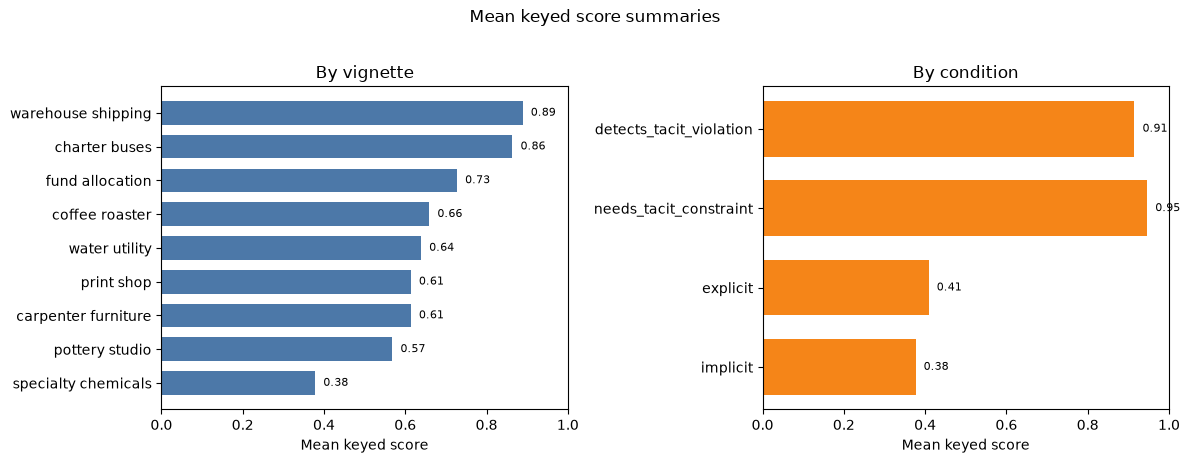

In [5]:
import matplotlib.pyplot as plt
import numpy as np

condition_col = "version" if "version" in plot_df.columns else "condition"
condition_order = [
    "implicit",
    "explicit",
    "needs_tacit_constraint",
    "detects_tacit_violation",
    "control",
]

vignette_scores = (
    plot_df.groupby("vignette_name", sort=False)["score_value"].mean()
)
# Keep vignette order from the data; sort bars ascending for readability.
vignette_scores = vignette_scores.reindex(
    plot_df["vignette_name"].drop_duplicates().tolist()
).sort_values(ascending=True)

condition_scores = (
    plot_df.groupby(condition_col, sort=False)["score_value"].mean()
)
present_conditions = [c for c in condition_order if c in condition_scores.index]
present_conditions += [
    c for c in condition_scores.index if c not in present_conditions
]
condition_scores = condition_scores.reindex(present_conditions)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

axes[0].barh(
    np.arange(len(vignette_scores)),
    vignette_scores.to_numpy(dtype=float),
    color="#4C78A8",
    height=0.7,
)
axes[0].set_yticks(np.arange(len(vignette_scores)))
axes[0].set_yticklabels(vignette_scores.index)
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("Mean keyed score")
axes[0].set_title("By vignette")
for y, value in enumerate(vignette_scores.to_numpy(dtype=float)):
    axes[0].text(min(value + 0.02, 0.98), y, f"{value:.2f}", va="center", fontsize=8)

axes[1].barh(
    np.arange(len(condition_scores)),
    condition_scores.to_numpy(dtype=float),
    color="#F58518",
    height=0.7,
)
axes[1].set_yticks(np.arange(len(condition_scores)))
axes[1].set_yticklabels(condition_scores.index)
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Mean keyed score")
axes[1].set_title("By condition")
for y, value in enumerate(condition_scores.to_numpy(dtype=float)):
    axes[1].text(min(value + 0.02, 0.98), y, f"{value:.2f}", va="center", fontsize=8)

fig.suptitle("Mean keyed score summaries", y=1.02)
fig.tight_layout()
plt.show()


## Mean score by constraint property × prompt kind

Vignettes are grouped by their **integer / sign** properties:

- **integers required** — tacit whole-number constraint (`integrality`)
- **nonnegativity required** — tacit non-negative constraint (`nonnegativity`)
- **fractional OK** — continuous amounts are valid (`fractional_ok`)
- **signed domain OK** — negative values can be valid (`signed_domain`)

Grouped bars: one cluster per **constraint property**; bar colors are prompt kinds (JSON `implicit` / `explicit`, plus audit variants). Height = mean keyed score across models and vignettes in the group (`0`–`1`).


Vignette groups:
  integers required: carpenter furniture, charter buses, pottery studio, print shop
  nonnegativity required: fund allocation, warehouse shipping
  fractional OK: coffee roaster, water utility
  signed domain OK: specialty chemicals


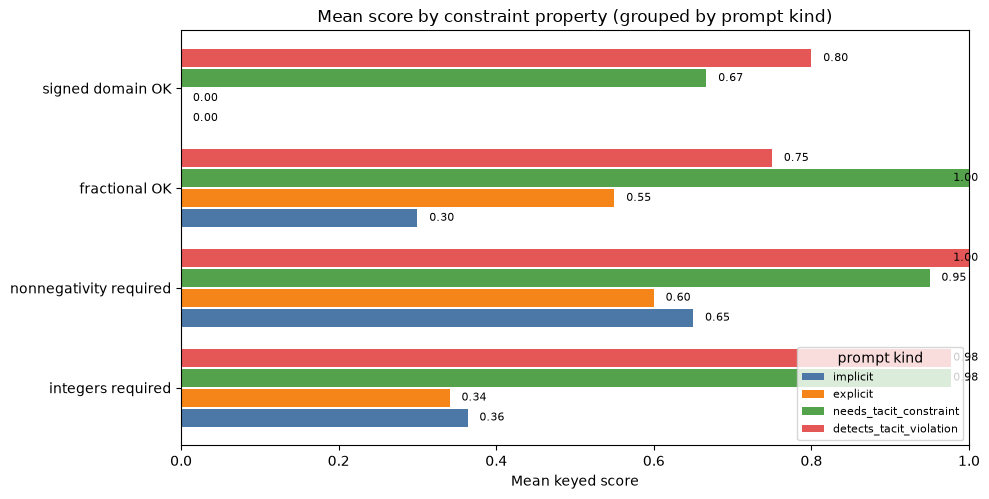

version,implicit,explicit,needs_tacit_constraint,detects_tacit_violation
constraint_property,,,,
integers required,0.364,0.341,0.977,0.977
nonnegativity required,0.650,0.600,0.950,1.000
fractional OK,0.300,0.550,1.000,0.750
signed domain OK,0.000,0.000,0.667,0.800


In [6]:
import matplotlib.pyplot as plt
import numpy as np

condition_col = "version" if "version" in plot_df.columns else "condition"
condition_order = [
    "implicit",
    "explicit",
    "needs_tacit_constraint",
    "detects_tacit_violation",
    "control",
]
property_order = [
    "integers required",
    "nonnegativity required",
    "fractional OK",
    "signed domain OK",
]
condition_colors = {
    "implicit": "#4C78A8",
    "explicit": "#F58518",
    "needs_tacit_constraint": "#54A24B",
    "detects_tacit_violation": "#E45756",
    "control": "#B279A2",
}


def _as_bool(value) -> bool:
    return str(value).strip().lower() in {"1", "true", "yes", "y"}


def _constraint_property(row) -> str:
    mode = str(row.get("failure_mode") or "").strip().lower()
    if mode == "integrality" or _as_bool(row.get("implicit_integer", False)):
        return "integers required"
    if mode == "nonnegativity" or _as_bool(row.get("implicit_nonnegative", False)):
        return "nonnegativity required"
    if mode == "fractional_ok":
        return "fractional OK"
    if mode == "signed_domain":
        return "signed domain OK"
    return mode or "other"


prop_df = plot_df.copy()
prop_df["constraint_property"] = prop_df.apply(_constraint_property, axis=1)

# Show which vignettes fall in each property group.
property_members = (
    prop_df[["constraint_property", "vignette_name"]]
    .drop_duplicates()
    .groupby("constraint_property")["vignette_name"]
    .apply(lambda s: ", ".join(sorted(s)))
    .reindex(property_order)
    .dropna()
)
print("Vignette groups:")
for prop, members in property_members.items():
    print(f"  {prop}: {members}")

pivot = (
    prop_df.groupby(["constraint_property", condition_col], sort=False)["score_value"]
    .mean()
    .unstack(condition_col)
)
present_props = [p for p in property_order if p in pivot.index]
present_props += [p for p in pivot.index if p not in present_props]
present_conditions = [c for c in condition_order if c in pivot.columns]
present_conditions += [c for c in pivot.columns if c not in present_conditions]
pivot = pivot.reindex(index=present_props, columns=present_conditions)

n_p = len(pivot.index)
n_c = len(present_conditions)
y = np.arange(n_p)
bar_height = 0.8 / max(n_c, 1)

fig, ax = plt.subplots(figsize=(10, max(4.5, 0.9 * n_p + 1.5)))
for i, cond in enumerate(present_conditions):
    offsets = y + (i - (n_c - 1) / 2) * bar_height
    values = pivot[cond].to_numpy(dtype=float)
    ax.barh(
        offsets,
        values,
        height=bar_height * 0.9,
        label=cond,
        color=condition_colors.get(cond, "#9D755D"),
    )
    for yi, value in zip(offsets, values):
        if np.isfinite(value):
            ax.text(min(value + 0.015, 0.98), yi, f"{value:.2f}", va="center", fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Mean keyed score")
ax.set_xlim(0, 1)
ax.set_title("Mean score by constraint property (grouped by prompt kind)")
ax.legend(title="prompt kind", loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()
pivot.round(3)


## Implicit − explicit score gap (vignette × LLM)

For each vignette, **JSON implicit score minus JSON explicit score** per model. Positive values mean the model scored higher when constraints were omitted; negative values mean spelling constraints out helped. Audit variants (`needs_tacit_constraint`, `detects_tacit_violation`) are omitted here.


In [7]:
_json = score_table.drop(columns=["mean"], errors="ignore")
if not isinstance(_json.index, pd.MultiIndex):
    raise ValueError("Expected MultiIndex on score_table")

# Prefer version labels from the new score table; fall back to condition.
level_names = list(_json.index.names)
level = "version" if "version" in level_names else "condition"
_json = _json[_json.index.get_level_values("vignette_name") != "mean"]
_implicit = _json.xs("implicit", level=level)
_explicit = _json.xs("explicit", level=level)

if "version" in plot_df.columns:
    vignette_order = (
        plot_df.loc[plot_df["version"].isin(["implicit", "explicit"]), "vignette_name"]
        .drop_duplicates()
        .tolist()
    )
else:
    vignette_order = (
        plot_df.loc[plot_df["condition"].isin(["implicit", "explicit"]), "vignette_name"]
        .drop_duplicates()
        .tolist()
    )

implicit_explicit_diff = _implicit.sub(_explicit).reindex(vignette_order)
implicit_explicit_diff = implicit_explicit_diff.sort_index(axis=1)
implicit_explicit_diff["mean"] = implicit_explicit_diff.mean(axis=1)

_col_means = implicit_explicit_diff.drop(columns=["mean"]).mean(axis=0)
_mean_row = _col_means.copy()
_mean_row["mean"] = float(_col_means.mean())
implicit_explicit_diff.loc["mean"] = _mean_row.to_numpy()

implicit_explicit_diff.round(3)


model,anthropic/claude-haiku-4-5@20251001,anthropic/claude-opus-4-8@default,anthropic/claude-opus-5@default,anthropic/claude-sonnet-4-6@default,google/gemini-2.5-flash,google/gemini-3-flash-preview,google/gemini-3.5-flash,google/gemini-3.5-flash-lite,google/gemini-3.6-flash,openai/gpt-5.6-sol,openai/gpt-5.6-terra,mean
vignette_name,,,,,,,,,,,,
carpenter furniture,0.0,0.000,0.000,0.000,0.0,0.000,0.0,0.0,0.0,0.000,0.000,0.000
charter buses,1.0,0.000,0.000,-1.000,0.0,0.000,0.0,0.0,0.0,0.000,0.000,0.000
coffee roaster,0.0,-1.000,-1.000,-1.000,0.0,0.000,0.0,0.0,0.0,1.000,-1.000,-0.273
fund allocation,0.0,0.000,0.000,1.000,0.0,0.000,0.0,0.0,0.0,0.000,0.000,0.091
pottery studio,0.0,-1.000,1.000,-1.000,0.0,0.000,0.0,0.0,0.0,0.000,0.000,-0.091
print shop,0.0,1.000,1.000,0.000,0.0,0.000,0.0,0.0,0.0,0.000,0.000,0.182
specialty chemicals,0.0,0.000,NaN,0.000,0.0,0.000,0.0,0.0,0.0,NaN,0.000,0.000
warehouse shipping,0.0,0.000,NaN,0.000,0.0,0.000,0.0,0.0,0.0,NaN,0.000,0.000
water utility,-1.0,0.000,NaN,0.000,0.0,-1.000,0.0,0.0,0.0,NaN,0.000,-0.222
